In [14]:
# Step 1: Import libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step 2: Load Dataset
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Step 3: Basic EDA
review_lengths = [len(i) for i in x_train]

print("Train samples:", len(x_train))
print("Test samples :", len(x_test))
print("Average review length:", int(np.mean(review_lengths)))
print("Max review length:", np.max(review_lengths))

Train samples: 25000
Test samples : 25000
Average review length: 238
Max review length: 2494


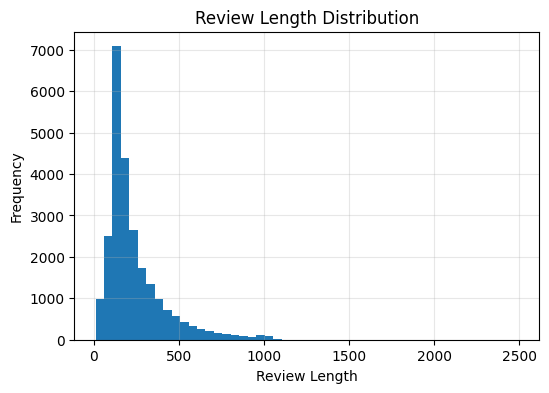

In [4]:
# 🎨 Visualization 1: Review Length Distribution
plt.figure(figsize=(6,4))
plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


In [5]:
plt.figure(figsize=(5,4))
labels = ["Negative", "Positive"]
counts = [np.sum(y_train == 0), np.sum(y_train == 1)]

<Figure size 500x400 with 0 Axes>

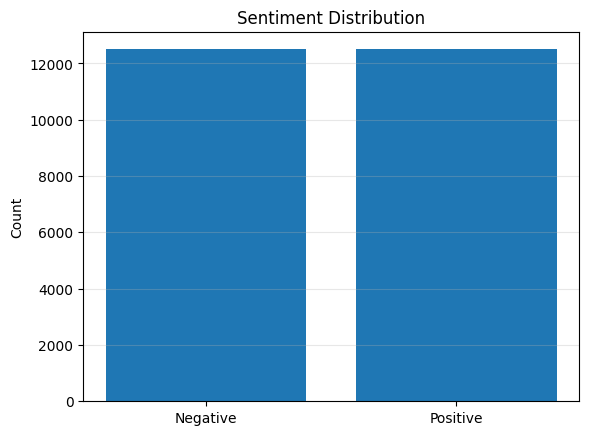

In [6]:
plt.bar(labels, counts)
plt.title("Sentiment Distribution")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [7]:
# Step 4: Preprocessing (Padding)
max_len = 200

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

In [8]:
# Step 5: Build CNN Model (with Dropout)
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),

    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),

    Dropout(0.5),   # ✅ Dropout layer

    Dense(64, activation='relu'),
    Dropout(0.5),   # ✅ Dropout again

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
# Step 6: Compile Model (Adam Optimizer)
# ------------------------------------------
model.compile(
    optimizer='adam',              # ✅ Adam used
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Step 7: Train Model
# ------------------------------------------
history = model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.6117 - loss: 0.6347 - val_accuracy: 0.7964 - val_loss: 0.4453
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8319 - loss: 0.3892 - val_accuracy: 0.8786 - val_loss: 0.3040
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9063 - loss: 0.2433 - val_accuracy: 0.8806 - val_loss: 0.2978


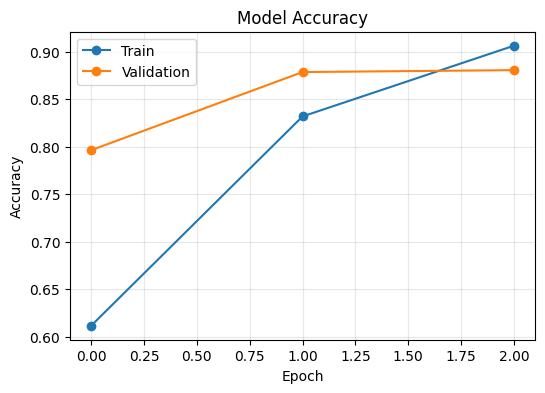

In [11]:
# 🎨 Visualization 3: Accuracy Curve
# ------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(alpha=0.3)
plt.show()

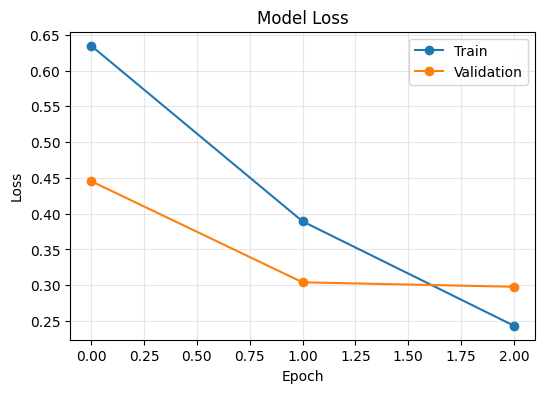

In [12]:
# 🎨 Visualization 4: Loss Curve
# ------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Step 8: Evaluate
# ------------------------------------------
loss, acc = model.evaluate(x_test, y_test)

print("\nFinal Accuracy:", round(acc * 100, 2), "%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8739 - loss: 0.2991

Final Accuracy: 87.39 %
